# 02 - Logo Annotation with Roboflow
## Bradford Bulls - AI Sponsorship Exposure Valuation System

**Workflow:**
1. Upload filtered frames (`frames_clear/`) to Roboflow
2. Annotate logos on Bradford Bulls players' jerseys (draw bounding boxes)
3. Apply augmentations for training robustness
4. Download annotated dataset in YOLOv8 format

**Prerequisites:**
- Run `01_video_to_frames.ipynb` first to extract frames
- Create a free account at [roboflow.com](https://roboflow.com)
- Get your API key from Roboflow Settings → API Key

## 1. Setup

In [1]:
# !pip install roboflow

import sys
sys.path.insert(0, "..")

import os
from pathlib import Path
from roboflow import Roboflow
import cv2
import matplotlib.pyplot as plt

from src.config import FRAMES_CLEAR_DIR, METADATA_DIR, SPONSOR_LABELS, OUTPUT_DIR

[Device] Using: cpu (CPU)


## 2. Configuration

Set your Roboflow API key and project details below.

In [2]:
# ============================================================
# ROBOFLOW CONFIGURATION
# ============================================================
ROBOFLOW_API_KEY = "Z7jfikrrq6dgA0YGrPua"  # Get from: app.roboflow.com → Settings → API Key

# WORKSPACE_NAME and PROJECT_NAME will be auto-detected below.
# If you already know them, you can set them here:
WORKSPACE_NAME = None  # Will be auto-detected
PROJECT_NAME = "kit-sponsor-logos"  # Must match the project you created on Roboflow UI

# Verify frames are available
clear_frames = sorted(FRAMES_CLEAR_DIR.glob("frame_*.jpg"))
print(f"Frames ready for annotation: {len(clear_frames)}")

if len(clear_frames) == 0:
    print("ERROR: No frames found. Run 01_video_to_frames.ipynb first!")
else:
    print(f"Source directory: {FRAMES_CLEAR_DIR}")

Frames ready for annotation: 6476
Source directory: c:\Users\Admin\Desktop\bradford_bulls\notebooks\..\output\frames_clear


## 3. Label Classes (Sponsor Logos)

These are the labels you will use when annotating in Roboflow.
Each label corresponds to a sponsor logo on the Bradford Bulls kit.

In [3]:
# Display all sponsor label classes
print("SPONSOR LABEL CLASSES FOR ANNOTATION")
print("=" * 50)
for label_id, label_name in SPONSOR_LABELS.items():
    print(f"  {label_id:<25s} → {label_name}")
print("=" * 50)
print(f"\nTotal classes: {len(SPONSOR_LABELS)}")
print("\nWhen annotating in Roboflow:")
print("1. Draw a bounding box around each visible logo")
print("2. Assign the correct label from the list above")
print("3. Only annotate logos on BRADFORD BULLS players")

SPONSOR LABEL CLASSES FOR ANNOTATION
  aon                       → AON
  atm_hospitality           → ATM Hospitality
  cch_cedar_court           → Cedar Court Hotels
  chadlaw                   → ChadLaw
  em_workwear               → EM Workwear
  fairway_flooring          → Fairway Flooring
  klg                       → KLG
  mcp                       → MCP
  mna_cladding              → MNA Cladding
  mna_support               → MNA Support Services
  bartercard                → Bartercard
  top_notch                 → Top Notch
  romantica_beds            → Romantica Beds

Total classes: 13

When annotating in Roboflow:
1. Draw a bounding box around each visible logo
2. Assign the correct label from the list above
3. Only annotate logos on BRADFORD BULLS players


## 4. Reference: Sponsor Logo Images

Preview the actual logos for reference during annotation.

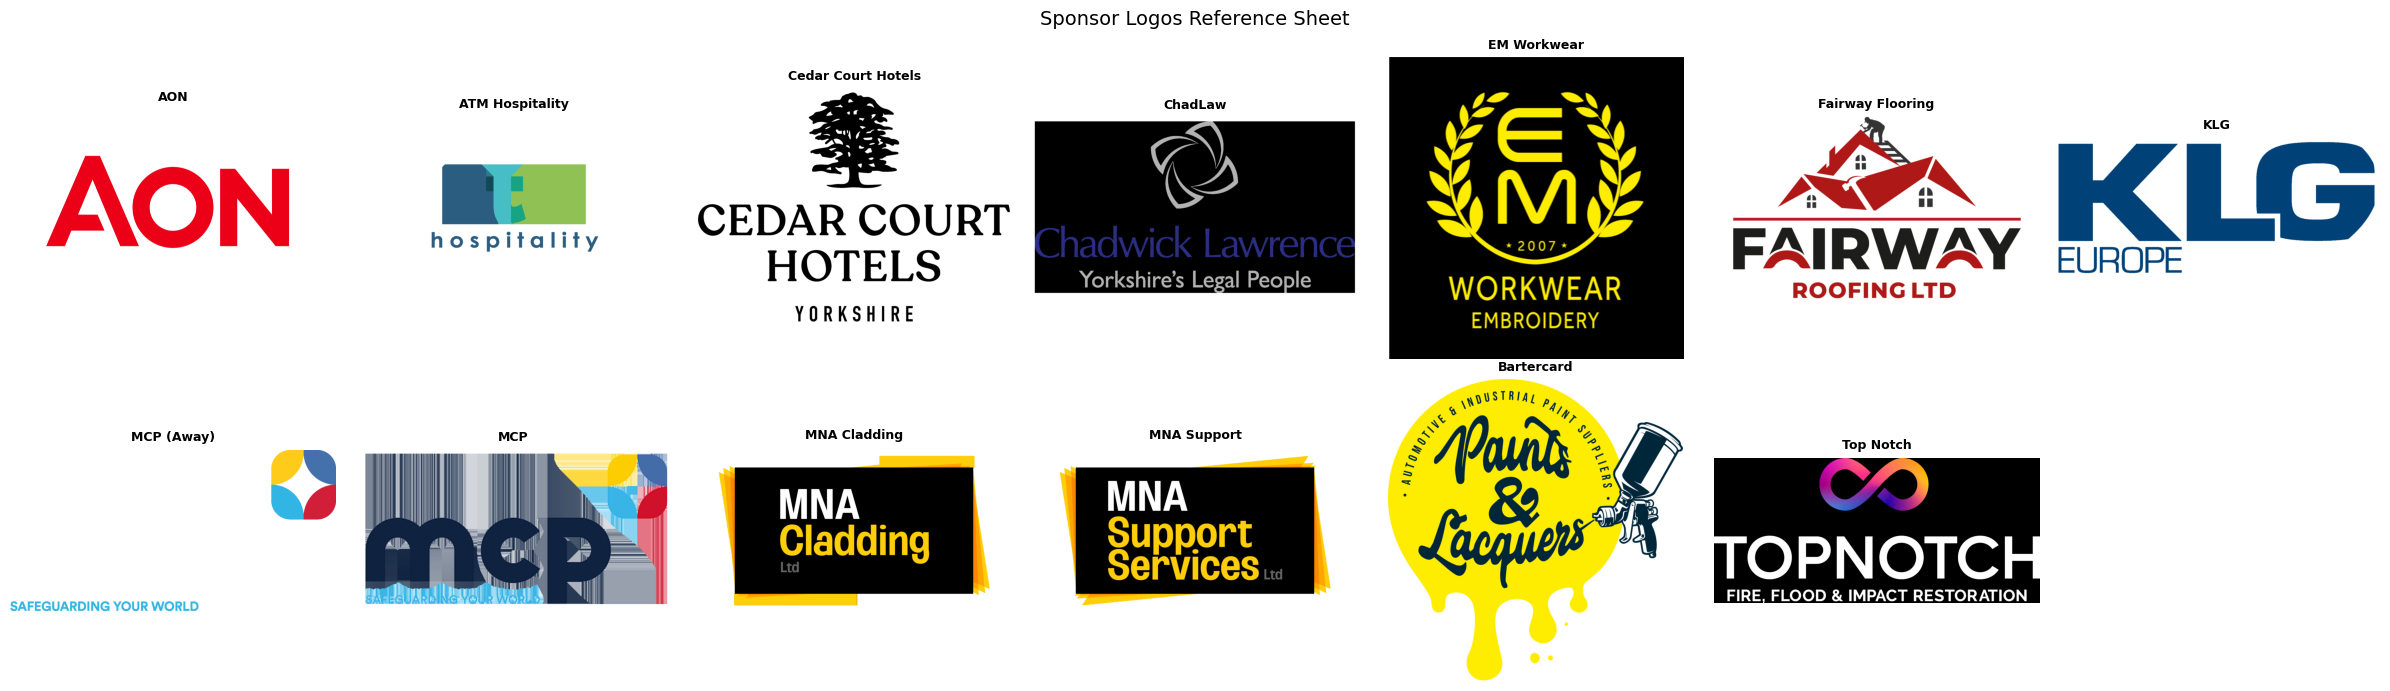

In [4]:
# Display sponsor logos for reference
from src.config import KIT_SPONSORS_DIR

logo_files = [
    ("AON", "1 - aon_logo_signature_red_rgb (2).png"),
    ("ATM Hospitality", "2 - ATM-Hospitality-Logo-New-Font.png"),
    ("Cedar Court Hotels", "3 - CCH - Master Logo Black [A3 Digital].png"),
    ("ChadLaw", "4 - ChadLaw1.png"),
    ("EM Workwear", "5 - EM workwear logo.png"),
    ("Fairway Flooring", "6 - Fairway Flooring Ltd Logo nO NUMBER.jpg"),
    ("KLG", "7 - KLG Transparent Final.png"),
    ("MCP (Away)", "8 - MCP Away.png"),
    ("MCP", "9 - MCP.png"),
    ("MNA Cladding", "10 - MNA Cladding.png"),
    ("MNA Support", "11 - MNA Support Services.png"),
    ("Bartercard", "12 - yellow.jpg"),
    ("Top Notch", "13 - Top Notch Logo.png"),
]

fig, axes = plt.subplots(2, 7, figsize=(24, 7))
axes = axes.flatten()

for i, (name, filename) in enumerate(logo_files):
    logo_path = KIT_SPONSORS_DIR / filename
    if logo_path.exists():
        img = cv2.imread(str(logo_path))
        if img is not None:
            axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(name, fontsize=9, fontweight="bold")
    axes[i].axis("off")

# Hide extra axes
for j in range(len(logo_files), len(axes)):
    axes[j].axis("off")

plt.suptitle("Sponsor Logos Reference Sheet", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Connect to Roboflow & Load Project

**IMPORTANT:** You must create the project manually on Roboflow first:
1. Go to [app.roboflow.com](https://app.roboflow.com) → **Create New Project**
2. Project Type: **Object Detection**
3. Project Name: `kit-sponsor-logos`
4. After creating, the cell below will auto-detect your workspace and connect.

In [5]:
# Connect to Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Auto-detect workspace
if WORKSPACE_NAME is None:
    workspace = rf.workspace()
    WORKSPACE_NAME = workspace.url
else:
    workspace = rf.workspace(WORKSPACE_NAME)

print(f"Workspace: {WORKSPACE_NAME}")

# Try to connect to existing project, or create it if it doesn't exist
try:
    project = workspace.project(PROJECT_NAME)
    print(f"Connected to existing project: {project.name}")
except Exception:
    print(f"Project '{PROJECT_NAME}' not accessible via API.")
    print(f"Creating project via API...")
    project = workspace.create_project(
        project_name="Kit Sponsor Logos",
        project_type="object-detection",
        project_license="MIT",
        annotation="kit-sponsor-logos",
    )
    print(f"Created project successfully!")

print(f"Project type: {project.type}")

loading Roboflow workspace...
Workspace: bradford-bulls
loading Roboflow project...
Connected to existing project: kit-sponsor-logos
Project type: object-detection


## 6. Upload Frames to Roboflow

Upload all frames from `frames_clear/` to the Roboflow project for annotation.

In [6]:
# Upload frames to Roboflow
from tqdm import tqdm

clear_frames = sorted(FRAMES_CLEAR_DIR.glob("frame_*.jpg"))
print(f"Uploading {len(clear_frames)} frames to Roboflow...")

success_count = 0
error_count = 0

for frame_path in tqdm(clear_frames, desc="Uploading"):
    try:
        project.upload(
            image_path=str(frame_path),
            split="train",  # Default split, can be changed in Roboflow UI
        )
        success_count += 1
    except Exception as e:
        error_count += 1
        if error_count <= 3:  # Only print first 3 errors
            print(f"  Error uploading {frame_path.name}: {e}")

print(f"\nUpload complete!")
print(f"  Success: {success_count}")
print(f"  Errors:  {error_count}")
print(f"\nGo to Roboflow to start annotating:")
print(f"  https://app.roboflow.com/{WORKSPACE_NAME}/{PROJECT_NAME}/annotate")

Uploading 6476 frames to Roboflow...


Uploading:   2%|▏         | 151/6476 [02:24<1:41:00,  1.04it/s]


KeyboardInterrupt: 

## 7. Annotation Guide

### How to annotate in Roboflow:

1. Go to your project's **Annotate** tab
2. For each frame:
   - Look for **Bradford Bulls players** (black & white/amber jerseys)
   - Draw a **bounding box** around each visible sponsor logo
   - Select the correct **label** from the class list
   - If a logo is partially visible (>50% visible), still annotate it
   - Skip logos that are too small or completely blurred

### Logo positions on the kit:
| Position | Sponsor | Label |
|----------|---------|-------|
| Main chest | AON | `aon` |
| Collar bone | ATM Hospitality | `atm_hospitality` |
| Chest (opp badge) | Cedar Court Hotels | `cch_cedar_court` |
| Sleeve 1 | ChadLaw | `chadlaw` |
| Sleeve 2 | MCP / Fairway Flooring | `mcp` / `fairway_flooring` |
| Sleeve 3 | EM Workwear | `em_workwear` |
| Top Back | KLG | `klg` |
| Bottom Back | Bartercard | `bartercard` |
| Shorts Front | MNA Cladding | `mna_cladding` |
| Shorts Back | MNA Support / Romantica | `mna_support` / `romantica_beds` |
| Socks | Top Notch | `top_notch` |

### Tips:
- **Prioritize quality over speed** — accurate annotations = better model
- Annotate at least **200-300 frames** for a good baseline model
- Use Roboflow's **Smart Polygon** or **Auto-Label** features to speed up

## 8. Download Annotated Dataset

After you finish annotating in Roboflow, generate a dataset version and download it here.

In [ ]:
# ============================================================
# DOWNLOAD ANNOTATED DATASET
# Run this AFTER completing annotation in Roboflow UI
# ============================================================

# First, create a "Version" in Roboflow with these recommended settings:
# - Preprocessing: Auto-Orient, Resize to 640x640
# - Augmentation: Flip Horizontal, Rotation ±15°, Brightness ±20%, Blur up to 2px
# Then come back here and run this cell.

DATASET_VERSION = 1  # Change this to your version number

dataset = project.version(DATASET_VERSION).download(
    model_format="yolov8",
    location=str(OUTPUT_DIR / "dataset")
)

print(f"\nDataset downloaded to: {dataset.location}")
print(f"  Train images: {dataset.location}/train/images/")
print(f"  Valid images: {dataset.location}/valid/images/")
print(f"  Labels:       {dataset.location}/train/labels/")
print(f"\nReady for Phase 2: Model Training (03_train_logo_detector.ipynb)")

In [ ]:
# Quick preview of downloaded dataset
import glob

dataset_path = OUTPUT_DIR / "dataset"
if dataset_path.exists():
    train_images = list((dataset_path / "train" / "images").glob("*.*"))
    train_labels = list((dataset_path / "train" / "labels").glob("*.txt"))
    valid_images = list((dataset_path / "valid" / "images").glob("*.*"))
    
    print(f"Dataset summary:")
    print(f"  Train images: {len(train_images)}")
    print(f"  Train labels: {len(train_labels)}")
    print(f"  Valid images: {len(valid_images)}")
    
    # Preview a labeled image
    if train_images:
        sample_img = cv2.imread(str(train_images[0]))
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Sample: {train_images[0].name}")
        plt.axis("off")
        plt.show()
        
        # Show its label
        label_file = dataset_path / "train" / "labels" / (train_images[0].stem + ".txt")
        if label_file.exists():
            print(f"\nLabel ({label_file.name}):")
            print(label_file.read_text())
else:
    print("Dataset not downloaded yet. Complete annotation first.")